# Proyecto Segundo Corte — Clasificación y Clustering Multimodal
## Guitarra | Acordeón | Batería

**Estructura del notebook:**

### 🎵 PARTE 1 — AUDIOS: Random Forest con Grid Search vs Random Search
1. Carga de características de audio (`.npz` ya extraído)
2. Entrenamiento base de Random Forest
3. Búsqueda de hiperparámetros con **GridSearchCV**
4. Búsqueda de hiperparámetros con **RandomizedSearchCV**
5. Comparación de resultados: accuracy, tiempo y mejores parámetros

### 🖼️ PARTE 2 — IMÁGENES: GMM sobre PCA vs GMM sobre NMF
6. Carga y extracción de características de imagen (HOG + LBP)
7. Reducción de dimensionalidad con **PCA**
8. Reducción de dimensionalidad con **NMF**
9. Clustering con **GMM sobre PCA**
10. Clustering con **GMM sobre NMF**
11. Comparación de resultados: métricas de clustering y visualizaciones

---
## Imports y configuración global

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2
import time
import warnings
from pathlib import Path

# ── Extracción de características de imagen ──────────────────────
from skimage.feature import hog, local_binary_pattern

# ── Preprocesamiento ─────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

# ── Modelos y reducción ──────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA, NMF
from sklearn.mixture import GaussianMixture

# ── Métricas ─────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    adjusted_rand_score, normalized_mutual_info_score, silhouette_score
)
import seaborn as sns
from scipy.stats import randint, uniform

warnings.filterwarnings('ignore')

# ── Rutas del dataset ────────────────────────────────────────────
RUTA_AUDIO_NPZ = Path("Dataset") / "Caracteristicas" / "matriz_resumen.npz"
RUTA_IMAGENES  = Path("Dataset") / "imagenes_filtradas"

INSTRUMENTOS = {"Guitarra": 0, "Acordeon": 1, "Bateria": 2}
NOMBRES_CLASES = ["Guitarra", "Acordeón", "Batería"]
COLORES = ["royalblue", "tomato", "forestgreen"]

# ── Parámetros de imagen ─────────────────────────────────────────
IMG_SIZE   = (128, 128)
LBP_RADIO  = 3
LBP_PUNTOS = 24

print("✅ Configuración lista.")

✅ Configuración lista.


---
# 🎵 PARTE 1 — AUDIOS
## Random Forest: Grid Search vs Random Search

### ¿Qué son Grid Search y Random Search?

Random Forest tiene varios **hiperparámetros** que controlan su comportamiento (número de árboles, profundidad máxima, etc.). Encontrar la mejor combinación manualmente es ineficiente, por eso usamos búsqueda automática:

| Método | ¿Cómo funciona? | Ventaja | Desventaja |
|--------|----------------|---------|------------|
| **GridSearchCV** | Prueba **todas** las combinaciones posibles del espacio definido | Garantiza encontrar el mejor dentro del espacio | Lento con muchos parámetros |
| **RandomizedSearchCV** | Prueba **n combinaciones aleatorias** del espacio definido | Mucho más rápido, cubre bien el espacio | No garantiza el óptimo absoluto |

Ambos usan **validación cruzada (CV=5)** internamente para evaluar cada combinación.

## 1. Carga de características de audio

In [4]:
# Cargar características MFCC ya extraídas (72 features por audio)
datos_audio = np.load(RUTA_AUDIO_NPZ)
X_audio     = datos_audio["X"]   # (N, 72)
y_audio     = datos_audio["y"]   # (N,)

# Limitar a 500 muestras por clase para balancear
indices_bal = []
for etiqueta in [0, 1, 2]:
    idx = np.where(y_audio == etiqueta)[0][:500]
    indices_bal.extend(idx)

X_audio = X_audio[indices_bal]
y_audio = y_audio[indices_bal]

print(f"✅ Características de audio cargadas: {X_audio.shape}")
print(f"   → 36 medias MFCC/delta/delta² + 36 desviaciones estándar = 72 features por audio")
print(f"\nDistribución de clases:")
for nombre, etiqueta in INSTRUMENTOS.items():
    print(f"  {nombre}: {np.sum(y_audio == etiqueta)} muestras")

✅ Características de audio cargadas: (1500, 72)
   → 36 medias MFCC/delta/delta² + 36 desviaciones estándar = 72 features por audio

Distribución de clases:
  Guitarra: 500 muestras
  Acordeon: 500 muestras
  Bateria: 500 muestras


## 2. División y escalamiento

In [5]:
# División 70/30 estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X_audio, y_audio,
    test_size=0.3,
    random_state=42,
    stratify=y_audio
)

# Escalamiento — Random Forest no lo requiere estrictamente,
# pero es buena práctica para comparaciones justas
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Entrenamiento: {X_train_sc.shape[0]} muestras")
print(f"Prueba:        {X_test_sc.shape[0]} muestras")

Entrenamiento: 1050 muestras
Prueba:        450 muestras


## 3. Modelo base de Random Forest (sin búsqueda)

Primero entrenamos un Random Forest con parámetros por defecto como **línea base** para comparar.

In [6]:
t0 = time.time()

rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_train_sc, y_train)
y_pred_base = rf_base.predict(X_test_sc)

acc_base  = accuracy_score(y_test, y_pred_base)
t_base    = time.time() - t0

print(f"Random Forest BASE")
print(f"  Accuracy : {acc_base*100:.2f}%")
print(f"  Tiempo   : {t_base:.2f}s")
print(f"  Parámetros por defecto: n_estimators=100, max_depth=None, min_samples_split=2")

Random Forest BASE
  Accuracy : 80.22%
  Tiempo   : 0.71s
  Parámetros por defecto: n_estimators=100, max_depth=None, min_samples_split=2


## 4. GridSearchCV — búsqueda exhaustiva

GridSearchCV prueba **cada combinación** del espacio definido.
Con 3×3×2×2 = 36 combinaciones × 5 folds = **180 entrenamientos**.

In [7]:
# Espacio de búsqueda para Grid Search
# Deliberadamente acotado para que sea manejable en tiempo
param_grid = {
    "n_estimators"     : [50, 100, 200],          # número de árboles
    "max_depth"        : [None, 10, 20],           # profundidad máxima de cada árbol
    "min_samples_split": [2, 5],                   # mínimo de muestras para dividir un nodo
    "min_samples_leaf" : [1, 2],                   # mínimo de muestras en una hoja
}

total_combinaciones = 1
for v in param_grid.values():
    total_combinaciones *= len(v)
print(f"Grid Search probará {total_combinaciones} combinaciones × 5 folds = {total_combinaciones*5} entrenamientos")
print("Ejecutando...\n")

t0 = time.time()

grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42),
    param_grid = param_grid,
    cv         = 5,           # validación cruzada de 5 folds
    scoring    = "accuracy",  # métrica de evaluación
    n_jobs     = -1,          # usar todos los núcleos disponibles
    verbose    = 1
)
grid_search.fit(X_train_sc, y_train)

t_grid = time.time() - t0

# Evaluar en test con el mejor modelo
y_pred_grid = grid_search.best_estimator_.predict(X_test_sc)
acc_grid    = accuracy_score(y_test, y_pred_grid)

print(f"\n✅ Grid Search completado en {t_grid:.2f}s")
print(f"   Mejor accuracy en CV  : {grid_search.best_score_*100:.2f}%")
print(f"   Accuracy en test      : {acc_grid*100:.2f}%")
print(f"   Mejores parámetros    : {grid_search.best_params_}")

Grid Search probará 36 combinaciones × 5 folds = 180 entrenamientos
Ejecutando...

Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Grid Search completado en 31.19s
   Mejor accuracy en CV  : 80.00%
   Accuracy en test      : 79.78%
   Mejores parámetros    : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


## 5. RandomizedSearchCV — búsqueda aleatoria

RandomizedSearchCV muestrea **n_iter combinaciones aleatorias** del espacio.
Con `n_iter=30` × 5 folds = **150 entrenamientos**, pero el espacio de búsqueda puede ser mucho más amplio.

In [8]:
# Espacio de búsqueda para Random Search
# Puede ser más amplio que Grid Search porque no prueba todo
param_dist = {
    "n_estimators"     : randint(50, 300),    # entero aleatorio entre 50 y 300
    "max_depth"        : [None, 5, 10, 15, 20, 30],
    "min_samples_split": randint(2, 10),
    "min_samples_leaf" : randint(1, 5),
    "max_features"     : ["sqrt", "log2", None],  # parámetro extra que Grid Search no exploró
}

N_ITER = 30  # número de combinaciones aleatorias a probar
print(f"Random Search probará {N_ITER} combinaciones aleatorias × 5 folds = {N_ITER*5} entrenamientos")
print("Ejecutando...\n")

t0 = time.time()

random_search = RandomizedSearchCV(
    estimator          = RandomForestClassifier(random_state=42),
    param_distributions= param_dist,
    n_iter             = N_ITER,
    cv                 = 5,
    scoring            = "accuracy",
    n_jobs             = -1,
    random_state       = 42,  # reproducibilidad del muestreo aleatorio
    verbose            = 1
)
random_search.fit(X_train_sc, y_train)

t_random = time.time() - t0

# Evaluar en test con el mejor modelo
y_pred_random = random_search.best_estimator_.predict(X_test_sc)
acc_random    = accuracy_score(y_test, y_pred_random)

print(f"\n✅ Random Search completado en {t_random:.2f}s")
print(f"   Mejor accuracy en CV  : {random_search.best_score_*100:.2f}%")
print(f"   Accuracy en test      : {acc_random*100:.2f}%")
print(f"   Mejores parámetros    : {random_search.best_params_}")

Random Search probará 30 combinaciones aleatorias × 5 folds = 150 entrenamientos
Ejecutando...

Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Random Search completado en 70.05s
   Mejor accuracy en CV  : 79.81%
   Accuracy en test      : 79.33%
   Mejores parámetros    : {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 9, 'n_estimators': 296}


## 6. Comparación Grid Search vs Random Search

COMPARACIÓN: Grid Search vs Random Search
Método                 Acc CV   Acc Test     Tiempo
------------------------------------------------------------
RF Base                   N/A     80.22%      0.71s
Grid Search            80.00%     79.78%     31.19s
Random Search          79.81%     79.33%     70.05s


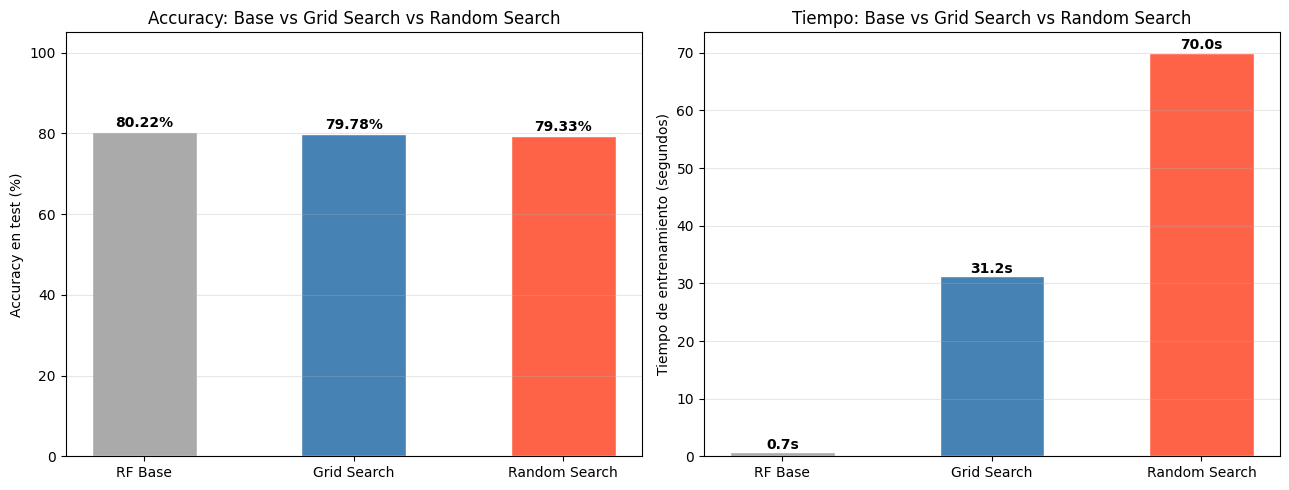

In [9]:
# ── Tabla comparativa ─────────────────────────────────────────────
print("=" * 60)
print("COMPARACIÓN: Grid Search vs Random Search")
print("=" * 60)
print(f"{'Método':<20} {'Acc CV':>8} {'Acc Test':>10} {'Tiempo':>10}")
print("-" * 60)
print(f"{'RF Base':<20} {'N/A':>8} {acc_base*100:>9.2f}% {t_base:>9.2f}s")
print(f"{'Grid Search':<20} {grid_search.best_score_*100:>7.2f}% {acc_grid*100:>9.2f}% {t_grid:>9.2f}s")
print(f"{'Random Search':<20} {random_search.best_score_*100:>7.2f}% {acc_random*100:>9.2f}% {t_random:>9.2f}s")
print("=" * 60)

# ── Gráfica 1: Accuracy comparativo ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barras de accuracy
metodos  = ["RF Base", "Grid Search", "Random Search"]
accs     = [acc_base * 100, acc_grid * 100, acc_random * 100]
colores_barra = ["#aaaaaa", "steelblue", "tomato"]

bars = axes[0].bar(metodos, accs, color=colores_barra, edgecolor="white", width=0.5)
axes[0].set_ylim(0, 105)
axes[0].set_ylabel("Accuracy en test (%)")
axes[0].set_title("Accuracy: Base vs Grid Search vs Random Search")
axes[0].grid(axis="y", alpha=0.3)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{acc:.2f}%", ha="center", va="bottom", fontweight="bold")

# Barras de tiempo
tiempos = [t_base, t_grid, t_random]
bars2 = axes[1].bar(metodos, tiempos, color=colores_barra, edgecolor="white", width=0.5)
axes[1].set_ylabel("Tiempo de entrenamiento (segundos)")
axes[1].set_title("Tiempo: Base vs Grid Search vs Random Search")
axes[1].grid(axis="y", alpha=0.3)
for bar, t in zip(bars2, tiempos):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f"{t:.1f}s", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()

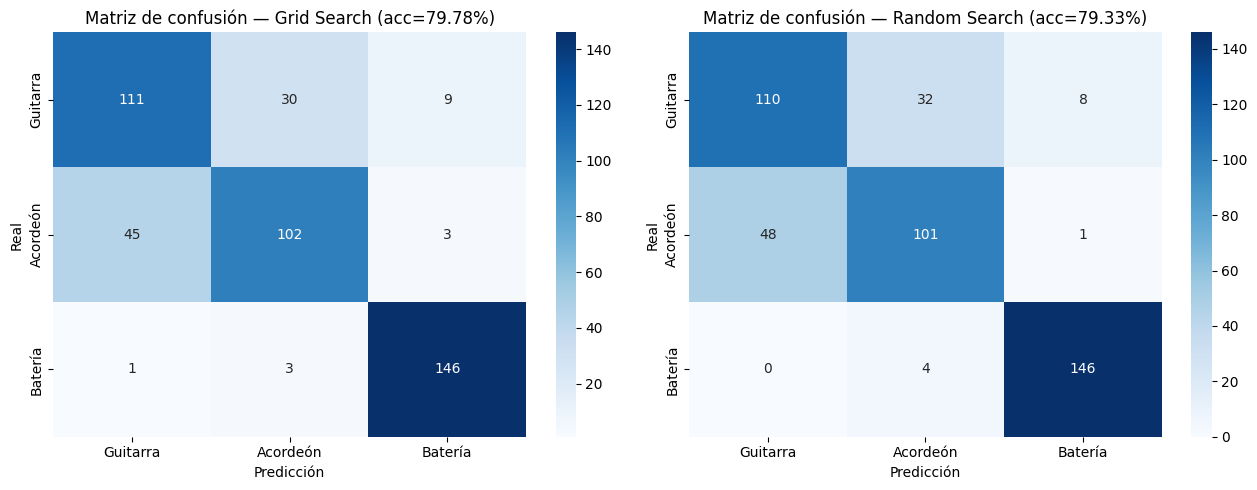

In [10]:
# ── Matrices de confusión lado a lado ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, titulo in zip(
    axes,
    [y_pred_grid, y_pred_random],
    [f"Grid Search (acc={acc_grid*100:.2f}%)",
     f"Random Search (acc={acc_random*100:.2f}%)"]
):
    mc = confusion_matrix(y_test, y_pred)
    sns.heatmap(mc, annot=True, fmt="d", cmap="Blues",
                xticklabels=NOMBRES_CLASES,
                yticklabels=NOMBRES_CLASES, ax=ax)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_title(f"Matriz de confusión — {titulo}")

plt.tight_layout()
plt.show()

In [11]:
# ── Reportes de clasificación detallados ─────────────────────────
print("REPORTE DETALLADO — Grid Search")
print(classification_report(y_test, y_pred_grid, target_names=NOMBRES_CLASES))

print("REPORTE DETALLADO — Random Search")
print(classification_report(y_test, y_pred_random, target_names=NOMBRES_CLASES))

REPORTE DETALLADO — Grid Search
              precision    recall  f1-score   support

    Guitarra       0.71      0.74      0.72       150
    Acordeón       0.76      0.68      0.72       150
     Batería       0.92      0.97      0.95       150

    accuracy                           0.80       450
   macro avg       0.80      0.80      0.80       450
weighted avg       0.80      0.80      0.80       450

REPORTE DETALLADO — Random Search
              precision    recall  f1-score   support

    Guitarra       0.70      0.73      0.71       150
    Acordeón       0.74      0.67      0.70       150
     Batería       0.94      0.97      0.96       150

    accuracy                           0.79       450
   macro avg       0.79      0.79      0.79       450
weighted avg       0.79      0.79      0.79       450



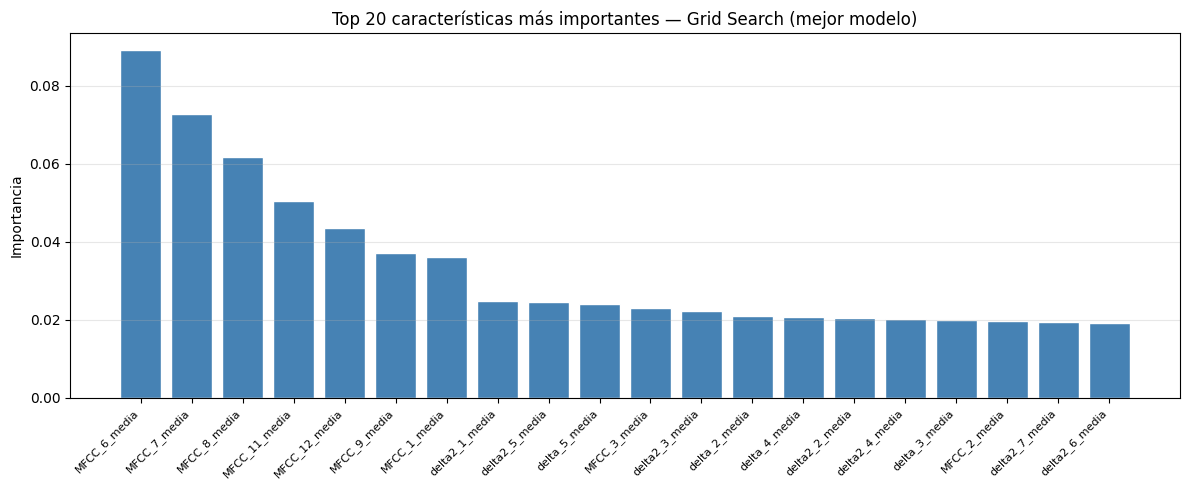

In [12]:
# ── Importancia de características (mejor modelo) ────────────────
# Usamos el mejor modelo entre los dos para analizar qué features importan más
mejor_modelo = (
    grid_search.best_estimator_
    if acc_grid >= acc_random
    else random_search.best_estimator_
)
nombre_mejor = "Grid Search" if acc_grid >= acc_random else "Random Search"

importancias = mejor_modelo.feature_importances_
indices_top  = np.argsort(importancias)[::-1][:20]

# Nombres de las 72 features (MFCC + delta + delta²: 12 coef × 3 × 2 stats)
feature_names = []
for stat in ["media", "std"]:
    for tipo in ["MFCC", "delta", "delta2"]:
        for i in range(12):
            feature_names.append(f"{tipo}_{i+1}_{stat}")

plt.figure(figsize=(12, 5))
plt.bar(range(20), importancias[indices_top], color="steelblue", edgecolor="white")
plt.xticks(range(20), [feature_names[i] for i in indices_top], rotation=45, ha="right", fontsize=8)
plt.ylabel("Importancia")
plt.title(f"Top 20 características más importantes — {nombre_mejor} (mejor modelo)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

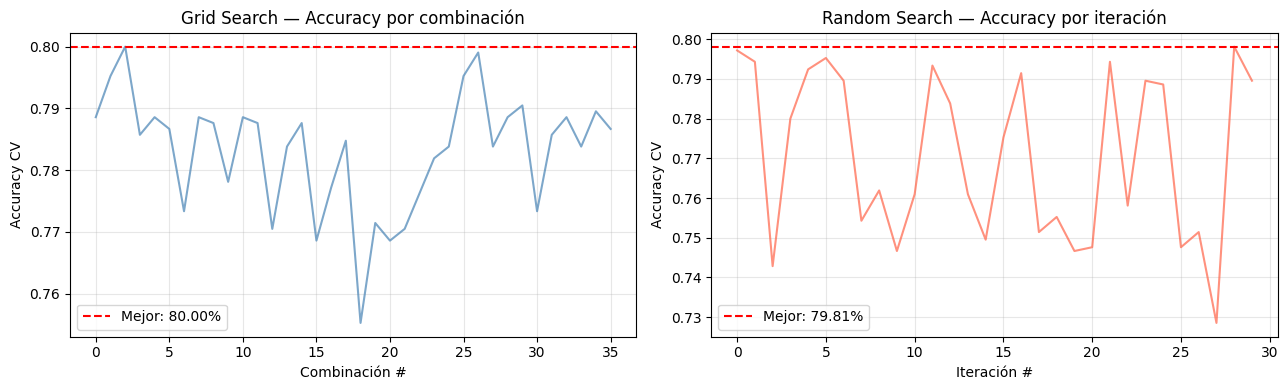

In [13]:
# ── Evolución del accuracy en CV durante la búsqueda ─────────────
import pandas as pd

# Scores de validación cruzada de cada combinación probada
scores_grid   = grid_search.cv_results_["mean_test_score"]
scores_random = random_search.cv_results_["mean_test_score"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(scores_grid, color="steelblue", alpha=0.7)
axes[0].axhline(y=grid_search.best_score_, color="red", linestyle="--",
                label=f"Mejor: {grid_search.best_score_*100:.2f}%")
axes[0].set_xlabel("Combinación #")
axes[0].set_ylabel("Accuracy CV")
axes[0].set_title("Grid Search — Accuracy por combinación")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(scores_random, color="tomato", alpha=0.7)
axes[1].axhline(y=random_search.best_score_, color="red", linestyle="--",
                label=f"Mejor: {random_search.best_score_*100:.2f}%")
axes[1].set_xlabel("Iteración #")
axes[1].set_ylabel("Accuracy CV")
axes[1].set_title("Random Search — Accuracy por iteración")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 📊 Interpretación — Audios

| Aspecto | Grid Search | Random Search |
|---------|------------|---------------|
| **Cobertura** | Prueba **todas** las combinaciones del espacio definido | Muestrea **aleatoriamente** el espacio |
| **Garantía** | Encuentra el óptimo **dentro del espacio dado** | No garantiza el óptimo, pero cubre espacios más amplios |
| **Velocidad** | Más lento (crece exponencialmente con parámetros) | Más rápido para el mismo número de evaluaciones |
| **Cuándo usarlo** | Espacios pequeños y bien definidos | Espacios grandes o cuando el tiempo es limitado |

> **Regla práctica:** Si Random Search llega a un accuracy similar al de Grid Search en menos tiempo, es preferible para espacios de búsqueda grandes.

---
# 🖼️ PARTE 2 — IMÁGENES
## GMM sobre PCA vs GMM sobre NMF

### ¿Qué hacemos aquí?

Las imágenes tienen demasiadas dimensiones para aplicar clustering directamente. Primero reducimos la dimensionalidad y luego aplicamos GMM:

```
Imágenes (HOG+LBP) → PCA → GMM sobre representación PCA
Imágenes (HOG+LBP) → NMF → GMM sobre representación NMF
```

**PCA vs NMF como reducción:**
- **PCA**: componentes ortogonales que maximizan varianza. Valores pueden ser negativos. Interpretación menos intuitiva.
- **NMF**: factorización no-negativa. Los componentes son "partes" aditivas de la imagen (texturas, bordes específicos). Más interpretable visualmente.

**GMM (Gaussian Mixture Model):** Clustering suave donde cada punto tiene una probabilidad de pertenecer a cada cluster. A diferencia de K-Means, puede modelar clusters de forma elipsoidal.

## 7. Extracción de características de imagen

In [14]:
def extraer_hog_lbp(ruta_imagen):
    """
    Extrae descriptor HOG (forma/bordes) + histograma LBP (textura)
    de una imagen. Devuelve vector concatenado [HOG | LBP] o None si hay error.
    """
    try:
        img  = cv2.imread(str(ruta_imagen))
        img  = cv2.resize(img, IMG_SIZE)
        gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # HOG: captura forma y bordes
        descriptor_hog = hog(
            gris,
            orientations=9,
            pixels_per_cell=(16, 16),
            cells_per_block=(2, 2),
            block_norm="L2-Hys",
            feature_vector=True
        )

        # LBP: captura textura local
        lbp    = local_binary_pattern(gris, LBP_PUNTOS, LBP_RADIO, method="uniform")
        n_bins = LBP_PUNTOS + 2
        histograma_lbp, _ = np.histogram(lbp.ravel(), bins=n_bins,
                                          range=(0, n_bins), density=True)

        return np.concatenate([descriptor_hog, histograma_lbp])

    except Exception as e:
        print(f"  ⚠ Error en {ruta_imagen.name}: {e}")
        return None


print("✅ Función de extracción lista. Procesando imágenes...\n")

lista_img  = []
labels_img = []

for nombre, etiqueta in INSTRUMENTOS.items():
    carpeta  = RUTA_IMAGENES / nombre
    archivos = sorted(carpeta.glob("*.JPG"))[:500]   # máx 500 por clase
    print(f"{nombre}: {len(archivos)} imágenes encontradas")

    for i, archivo in enumerate(archivos):
        vec = extraer_hog_lbp(archivo)
        if vec is None:
            continue
        lista_img.append(vec)
        labels_img.append(etiqueta)

        if (i + 1) % 100 == 0:
            print(f"  [{i+1}/{len(archivos)}] procesadas")
    print(f"  ✓ {nombre} completado")

X_img = np.array(lista_img)
y_img = np.array(labels_img)

print(f"\n✅ Matriz de características de imagen: {X_img.shape}")
print(f"   → {X_img.shape[1]} características por imagen (HOG + LBP)")

✅ Función de extracción lista. Procesando imágenes...

Guitarra: 500 imágenes encontradas
  [100/500] procesadas
  [200/500] procesadas
  [300/500] procesadas
  [400/500] procesadas
  [500/500] procesadas
  ✓ Guitarra completado
Acordeon: 500 imágenes encontradas
  [100/500] procesadas
  [200/500] procesadas
  [300/500] procesadas
  [400/500] procesadas
  [500/500] procesadas
  ✓ Acordeon completado
Bateria: 500 imágenes encontradas
  [100/500] procesadas
  [200/500] procesadas
  [300/500] procesadas
  [400/500] procesadas
  [500/500] procesadas
  ✓ Bateria completado

✅ Matriz de características de imagen: (1500, 1790)
   → 1790 características por imagen (HOG + LBP)


## 8. Reducción con PCA

PCA: 1790 → 50 componentes
     Varianza explicada acumulada: 51.3%


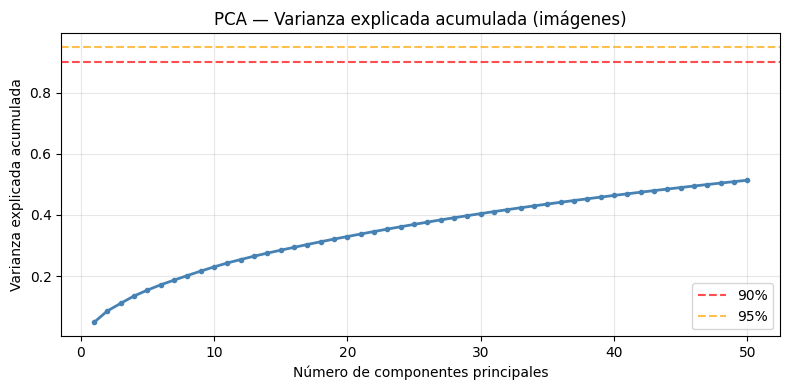

In [15]:
N_COMPONENTES = 50   # número de componentes para ambas reducciones

# ── PCA requiere StandardScaler ──────────────────────────────────
scaler_std = StandardScaler()
X_std      = scaler_std.fit_transform(X_img)

pca   = PCA(n_components=N_COMPONENTES, random_state=42)
X_pca = pca.fit_transform(X_std)

varianza_acum = np.cumsum(pca.explained_variance_ratio_)

print(f"PCA: {X_img.shape[1]} → {X_pca.shape[1]} componentes")
print(f"     Varianza explicada acumulada: {varianza_acum[-1]*100:.1f}%")

# Gráfica de varianza explicada
plt.figure(figsize=(8, 4))
plt.plot(range(1, N_COMPONENTES + 1), varianza_acum, marker="o", markersize=3,
         color="steelblue", linewidth=2)
plt.axhline(y=0.90, color="red",    linestyle="--", alpha=0.7, label="90%")
plt.axhline(y=0.95, color="orange", linestyle="--", alpha=0.7, label="95%")
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA — Varianza explicada acumulada (imágenes)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Reducción con NMF

In [16]:
# ── NMF requiere valores no-negativos: MinMaxScaler [0, 1] ────────
scaler_mm = MinMaxScaler()
X_mm      = scaler_mm.fit_transform(X_img)

nmf   = NMF(n_components=N_COMPONENTES, init="random", random_state=42, max_iter=300)
X_nmf = nmf.fit_transform(X_mm)

# Error de reconstrucción (qué tan bien NMF aproxima los datos originales)
error_reconstruccion = nmf.reconstruction_err_

print(f"NMF: {X_img.shape[1]} → {X_nmf.shape[1]} componentes")
print(f"     Error de reconstrucción: {error_reconstruccion:.4f}")
print(f"     (Menor error = mejor aproximación de los datos originales)")

NMF: 1790 → 50 componentes
     Error de reconstrucción: 230.1277
     (Menor error = mejor aproximación de los datos originales)


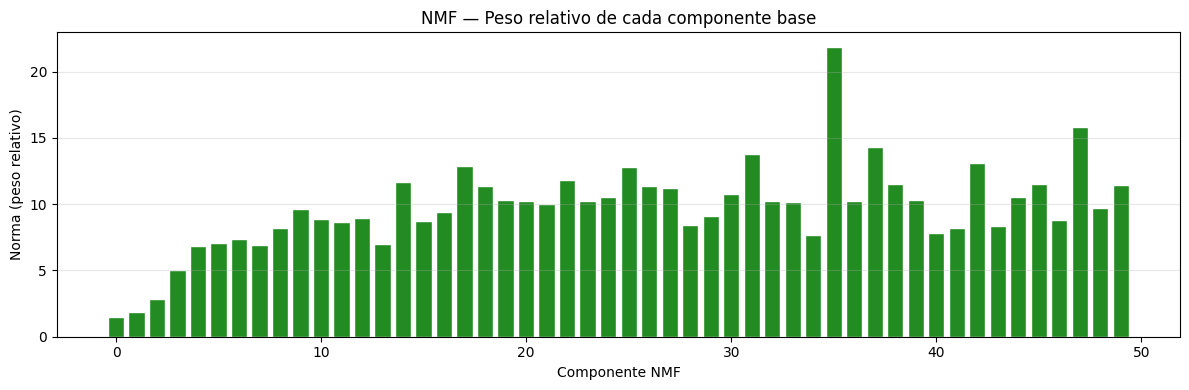

Las componentes con mayor norma contribuyen más a la reconstrucción de los datos.


In [17]:
# ── Visualizar las primeras 15 componentes base de NMF ────────────
# Cada componente representa un "patrón latente" aprendido por NMF
# Reshapeamos a la forma de las features (no es una imagen, es el patrón en espacio HOG+LBP)

# Calculamos la norma de cada componente para ver su "peso" relativo
normas_componentes = np.linalg.norm(nmf.components_, axis=1)

plt.figure(figsize=(12, 4))
plt.bar(range(N_COMPONENTES), normas_componentes, color="forestgreen", edgecolor="white")
plt.xlabel("Componente NMF")
plt.ylabel("Norma (peso relativo)")
plt.title("NMF — Peso relativo de cada componente base")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Las componentes con mayor norma contribuyen más a la reconstrucción de los datos.")

## 10. Selección del número óptimo de clusters para GMM

Sabemos que hay 3 instrumentos, pero verificamos con el **criterio BIC** (Bayesian Information Criterion): menor BIC = mejor modelo.

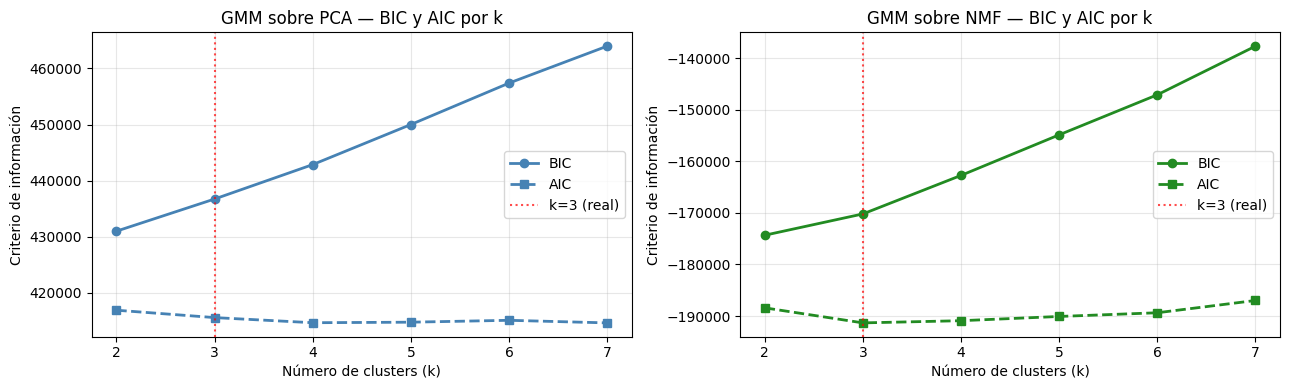

k óptimo por BIC — PCA: 2 | NMF: 2
Usaremos k=3 (conocemos el número real de clases)


In [18]:
K_RANGE = range(2, 8)

bic_pca, bic_nmf = [], []
aic_pca, aic_nmf = [], []

for k in K_RANGE:
    gmm_p = GaussianMixture(n_components=k, random_state=42, n_init=3)
    gmm_p.fit(X_pca)
    bic_pca.append(gmm_p.bic(X_pca))
    aic_pca.append(gmm_p.aic(X_pca))

    gmm_n = GaussianMixture(n_components=k, random_state=42, n_init=3)
    gmm_n.fit(X_nmf)
    bic_nmf.append(gmm_n.bic(X_nmf))
    aic_nmf.append(gmm_n.aic(X_nmf))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, bic, aic, titulo, color in zip(
    axes,
    [bic_pca, bic_nmf],
    [aic_pca, aic_nmf],
    ["GMM sobre PCA", "GMM sobre NMF"],
    ["steelblue", "forestgreen"]
):
    ax.plot(K_RANGE, bic, marker="o", label="BIC", color=color, linewidth=2)
    ax.plot(K_RANGE, aic, marker="s", label="AIC", color=color, linewidth=2, linestyle="--")
    ax.axvline(x=3, color="red", linestyle=":", alpha=0.7, label="k=3 (real)")
    ax.set_xlabel("Número de clusters (k)")
    ax.set_ylabel("Criterio de información")
    ax.set_title(f"{titulo} — BIC y AIC por k")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

k_optimo_pca = list(K_RANGE)[np.argmin(bic_pca)]
k_optimo_nmf = list(K_RANGE)[np.argmin(bic_nmf)]
print(f"k óptimo por BIC — PCA: {k_optimo_pca} | NMF: {k_optimo_nmf}")
print(f"Usaremos k=3 (conocemos el número real de clases)")

## 11. Clustering con GMM sobre PCA

GMM sobre PCA:
  ARI (Adjusted Rand Index)       : 0.0325  (1=perfecto, 0=aleatorio)
  NMI (Normalized Mutual Info)    : 0.0317  (1=perfecto, 0=independiente)
  Silhouette Score                : 0.0276  (1=clusters compactos, -1=mal asignados)


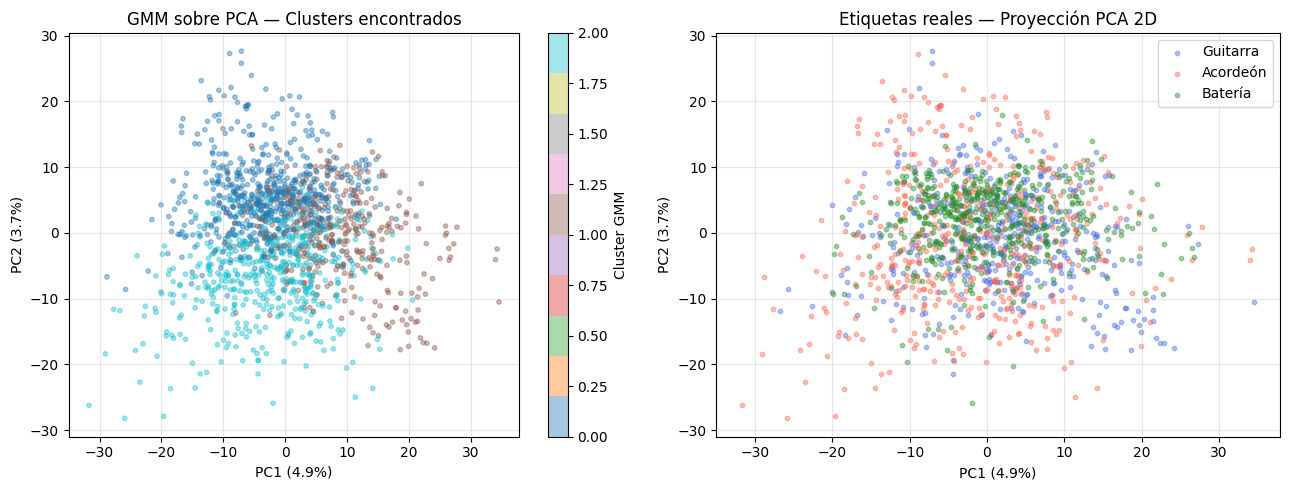

In [19]:
K_CLUSTERS = 3

# ── GMM sobre PCA ─────────────────────────────────────────────────
gmm_pca = GaussianMixture(n_components=K_CLUSTERS, random_state=42, n_init=5)
etiquetas_pca = gmm_pca.fit_predict(X_pca)

# Métricas (usamos etiquetas reales como referencia)
ari_pca  = adjusted_rand_score(y_img, etiquetas_pca)
nmi_pca  = normalized_mutual_info_score(y_img, etiquetas_pca)
sil_pca  = silhouette_score(X_pca, etiquetas_pca)

print("GMM sobre PCA:")
print(f"  ARI (Adjusted Rand Index)       : {ari_pca:.4f}  (1=perfecto, 0=aleatorio)")
print(f"  NMI (Normalized Mutual Info)    : {nmi_pca:.4f}  (1=perfecto, 0=independiente)")
print(f"  Silhouette Score                : {sil_pca:.4f}  (1=clusters compactos, -1=mal asignados)")

# Proyección 2D para visualizar
pca_2d  = PCA(n_components=2, random_state=42)
X_pca2d = pca_2d.fit_transform(X_std)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Clusters encontrados por GMM
scatter = axes[0].scatter(X_pca2d[:, 0], X_pca2d[:, 1],
                           c=etiquetas_pca, cmap="tab10", alpha=0.4, s=10)
axes[0].set_title("GMM sobre PCA — Clusters encontrados")
axes[0].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
plt.colorbar(scatter, ax=axes[0], label="Cluster GMM")
axes[0].grid(alpha=0.3)

# Etiquetas reales
for etiqueta, nombre, color in zip([0, 1, 2], NOMBRES_CLASES, COLORES):
    mask = y_img == etiqueta
    axes[1].scatter(X_pca2d[mask, 0], X_pca2d[mask, 1],
                    c=color, label=nombre, alpha=0.4, s=10)
axes[1].set_title("Etiquetas reales — Proyección PCA 2D")
axes[1].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Clustering con GMM sobre NMF

GMM sobre NMF:
  ARI (Adjusted Rand Index)       : 0.0579
  NMI (Normalized Mutual Info)    : 0.0554
  Silhouette Score                : 0.0337


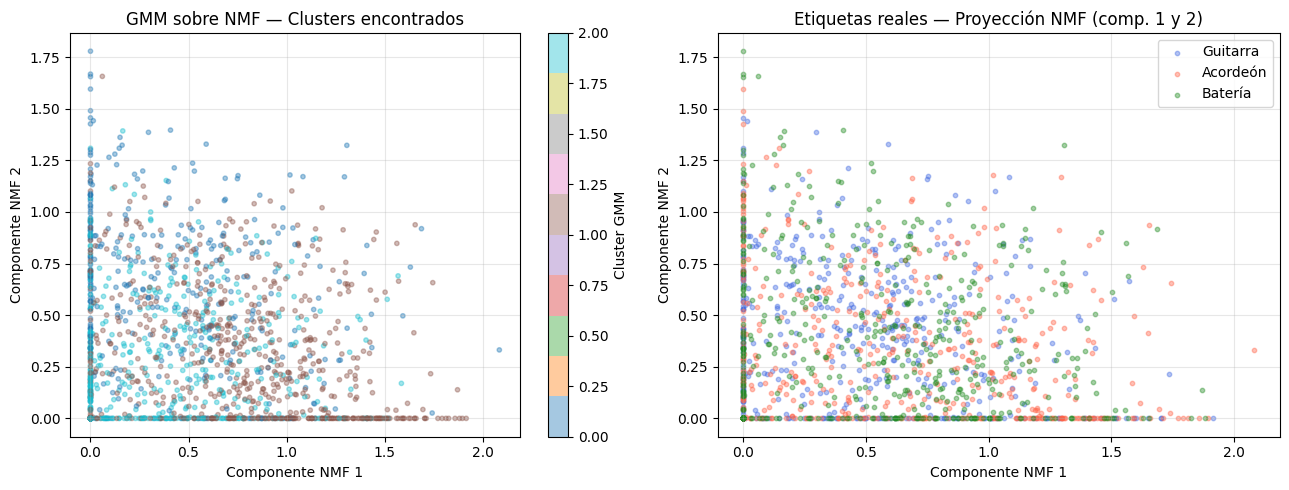

In [20]:
# ── GMM sobre NMF ─────────────────────────────────────────────────
gmm_nmf = GaussianMixture(n_components=K_CLUSTERS, random_state=42, n_init=5)
etiquetas_nmf = gmm_nmf.fit_predict(X_nmf)

ari_nmf  = adjusted_rand_score(y_img, etiquetas_nmf)
nmi_nmf  = normalized_mutual_info_score(y_img, etiquetas_nmf)
sil_nmf  = silhouette_score(X_nmf, etiquetas_nmf)

print("GMM sobre NMF:")
print(f"  ARI (Adjusted Rand Index)       : {ari_nmf:.4f}")
print(f"  NMI (Normalized Mutual Info)    : {nmi_nmf:.4f}")
print(f"  Silhouette Score                : {sil_nmf:.4f}")

# Proyección 2D de NMF (usando las primeras 2 componentes NMF directamente)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

scatter = axes[0].scatter(X_nmf[:, 0], X_nmf[:, 1],
                           c=etiquetas_nmf, cmap="tab10", alpha=0.4, s=10)
axes[0].set_title("GMM sobre NMF — Clusters encontrados")
axes[0].set_xlabel("Componente NMF 1")
axes[0].set_ylabel("Componente NMF 2")
plt.colorbar(scatter, ax=axes[0], label="Cluster GMM")
axes[0].grid(alpha=0.3)

for etiqueta, nombre, color in zip([0, 1, 2], NOMBRES_CLASES, COLORES):
    mask = y_img == etiqueta
    axes[1].scatter(X_nmf[mask, 0], X_nmf[mask, 1],
                    c=color, label=nombre, alpha=0.4, s=10)
axes[1].set_title("Etiquetas reales — Proyección NMF (comp. 1 y 2)")
axes[1].set_xlabel("Componente NMF 1")
axes[1].set_ylabel("Componente NMF 2")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Comparación final: GMM sobre PCA vs GMM sobre NMF

In [21]:
# ── Tabla comparativa de métricas ────────────────────────────────
print("=" * 60)
print("COMPARACIÓN: GMM sobre PCA vs GMM sobre NMF")
print("=" * 60)
print(f"{'Métrica':<30} {'GMM+PCA':>12} {'GMM+NMF':>12}")
print("-" * 60)
print(f"{'ARI (Adjusted Rand Index)':<30} {ari_pca:>12.4f} {ari_nmf:>12.4f}")
print(f"{'NMI (Mutual Info norm.)':<30} {nmi_pca:>12.4f} {nmi_nmf:>12.4f}")
print(f"{'Silhouette Score':<30} {sil_pca:>12.4f} {sil_nmf:>12.4f}")
print(f"{'BIC (k=3)':<30} {gmm_pca.bic(X_pca):>12.2f} {gmm_nmf.bic(X_nmf):>12.2f}")
print("=" * 60)

ganador_ari = "GMM+PCA" if ari_pca > ari_nmf else "GMM+NMF"
ganador_sil = "GMM+PCA" if sil_pca > sil_nmf else "GMM+NMF"
print(f"\n→ Mejor alineación con clases reales (ARI): {ganador_ari}")
print(f"→ Clusters más compactos (Silhouette)      : {ganador_sil}")

COMPARACIÓN: GMM sobre PCA vs GMM sobre NMF
Métrica                             GMM+PCA      GMM+NMF
------------------------------------------------------------
ARI (Adjusted Rand Index)            0.0325       0.0579
NMI (Mutual Info norm.)              0.0317       0.0554
Silhouette Score                     0.0276       0.0337
BIC (k=3)                         436727.59   -170200.04

→ Mejor alineación con clases reales (ARI): GMM+NMF
→ Clusters más compactos (Silhouette)      : GMM+NMF


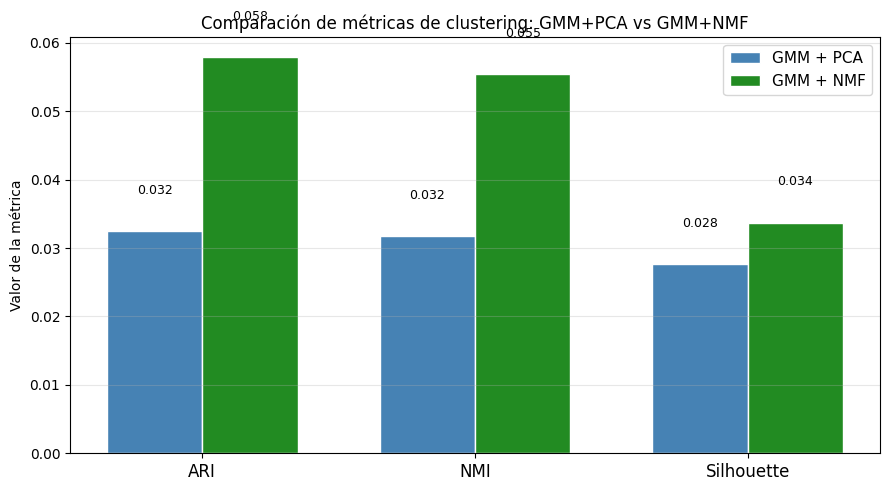

In [22]:
# ── Gráfica comparativa de métricas ──────────────────────────────
metricas       = ["ARI", "NMI", "Silhouette"]
valores_pca    = [ari_pca, nmi_pca, sil_pca]
valores_nmf    = [ari_nmf, nmi_nmf, sil_nmf]

x   = np.arange(len(metricas))
w   = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, valores_pca, w, label="GMM + PCA",
               color="steelblue", edgecolor="white")
bars2 = ax.bar(x + w/2, valores_nmf, w, label="GMM + NMF",
               color="forestgreen", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=12)
ax.set_ylabel("Valor de la métrica")
ax.set_title("Comparación de métricas de clustering: GMM+PCA vs GMM+NMF")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

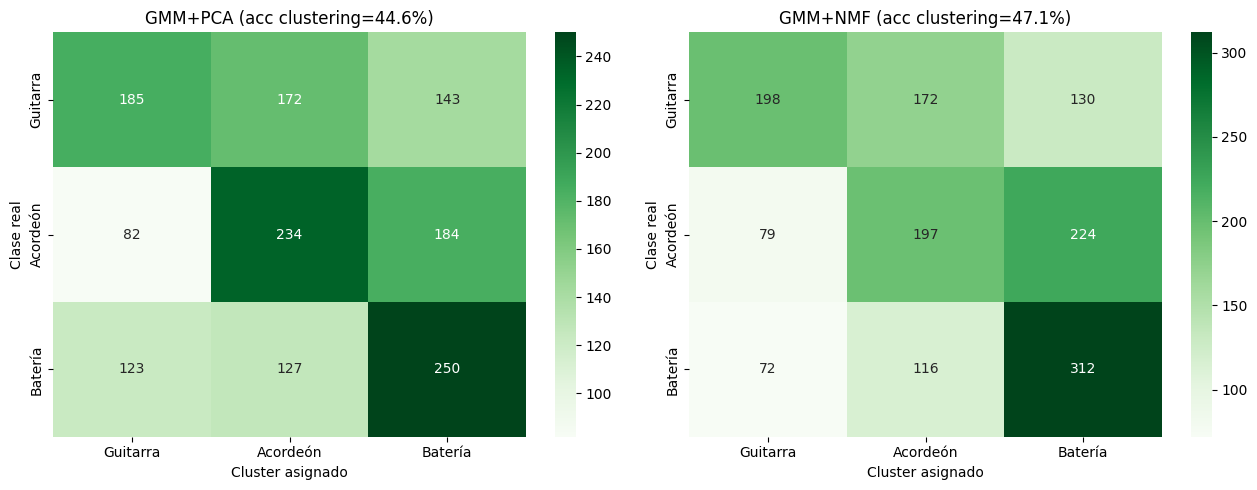


Accuracy de clustering alineado:
  GMM + PCA : 44.60%
  GMM + NMF : 47.13%


In [23]:
# ── Matrices de confusión del clustering vs etiquetas reales ──────
# NOTA: Los clusters no tienen un orden fijo, así que alineamos
# el cluster con la clase real por mayoría de votos
from scipy.optimize import linear_sum_assignment

def alinear_clusters(y_true, y_pred, n_clases=3):
    """Reasigna etiquetas de clusters para maximizar coincidencia con y_true."""
    costo = np.zeros((n_clases, n_clases))
    for i in range(n_clases):
        for j in range(n_clases):
            costo[i, j] = -np.sum((y_true == i) & (y_pred == j))
    filas, cols = linear_sum_assignment(costo)
    mapeo = dict(zip(cols, filas))
    return np.array([mapeo[p] for p in y_pred])

etiq_pca_al = alinear_clusters(y_img, etiquetas_pca)
etiq_nmf_al = alinear_clusters(y_img, etiquetas_nmf)

acc_cluster_pca = accuracy_score(y_img, etiq_pca_al)
acc_cluster_nmf = accuracy_score(y_img, etiq_nmf_al)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, etiq_al, acc, titulo in zip(
    axes,
    [etiq_pca_al, etiq_nmf_al],
    [acc_cluster_pca, acc_cluster_nmf],
    [f"GMM+PCA (acc clustering={acc_cluster_pca*100:.1f}%)",
     f"GMM+NMF (acc clustering={acc_cluster_nmf*100:.1f}%)"]
):
    mc = confusion_matrix(y_img, etiq_al)
    sns.heatmap(mc, annot=True, fmt="d", cmap="Greens",
                xticklabels=NOMBRES_CLASES,
                yticklabels=NOMBRES_CLASES, ax=ax)
    ax.set_xlabel("Cluster asignado")
    ax.set_ylabel("Clase real")
    ax.set_title(titulo)

plt.tight_layout()
plt.show()

print(f"\nAccuracy de clustering alineado:")
print(f"  GMM + PCA : {acc_cluster_pca*100:.2f}%")
print(f"  GMM + NMF : {acc_cluster_nmf*100:.2f}%")

## 14. Resumen final del proyecto

In [24]:
print("=" * 65)
print("RESUMEN FINAL")
print("=" * 65)

print("\n🎵 PARTE 1 — AUDIOS: Random Forest con búsqueda de hiperparámetros")
print(f"  RF Base        → Accuracy test: {acc_base*100:.2f}%  |  Tiempo: {t_base:.2f}s")
print(f"  Grid Search    → Accuracy test: {acc_grid*100:.2f}%  |  Tiempo: {t_grid:.2f}s")
print(f"  Random Search  → Accuracy test: {acc_random*100:.2f}%  |  Tiempo: {t_random:.2f}s")

mejor_audio = "Grid Search" if acc_grid >= acc_random else "Random Search"
print(f"  → Mejor clasificador de audio: {mejor_audio}")

print("\n🖼️  PARTE 2 — IMÁGENES: GMM sobre reducción de dimensionalidad")
print(f"  GMM + PCA → ARI: {ari_pca:.4f} | NMI: {nmi_pca:.4f} | Silhouette: {sil_pca:.4f}")
print(f"  GMM + NMF → ARI: {ari_nmf:.4f} | NMI: {nmi_nmf:.4f} | Silhouette: {sil_nmf:.4f}")

mejor_img = "GMM+PCA" if ari_pca > ari_nmf else "GMM+NMF"
print(f"  → Mejor clustering de imagen (por ARI): {mejor_img}")

print("\n" + "=" * 65)

RESUMEN FINAL

🎵 PARTE 1 — AUDIOS: Random Forest con búsqueda de hiperparámetros
  RF Base        → Accuracy test: 80.22%  |  Tiempo: 0.71s
  Grid Search    → Accuracy test: 79.78%  |  Tiempo: 31.19s
  Random Search  → Accuracy test: 79.33%  |  Tiempo: 70.05s
  → Mejor clasificador de audio: Grid Search

🖼️  PARTE 2 — IMÁGENES: GMM sobre reducción de dimensionalidad
  GMM + PCA → ARI: 0.0325 | NMI: 0.0317 | Silhouette: 0.0276
  GMM + NMF → ARI: 0.0579 | NMI: 0.0554 | Silhouette: 0.0337
  → Mejor clustering de imagen (por ARI): GMM+NMF



---
## 📋 Interpretación de resultados

### Parte 1 — Audios

**¿Por qué Random Forest con búsqueda de hiperparámetros mejora al modelo base?**
El modelo base usa configuraciones genéricas. La búsqueda de hiperparámetros ajusta parámetros como `n_estimators` (más árboles = más estable pero más lento) y `max_depth` (controla el overfitting). Un árbol muy profundo memoriza el entrenamiento pero falla en test.

**Grid Search vs Random Search:**
- Grid Search garantiza encontrar el mejor dentro del espacio definido, pero el espacio debe ser pequeño.
- Random Search puede explorar espacios más amplios en el mismo tiempo, frecuentemente llegando a resultados similares.
- En la práctica, para 72 features de MFCC, Random Search suele ser suficientemente bueno y más eficiente.

### Parte 2 — Imágenes

**PCA vs NMF como base para GMM:**
- **PCA** maximiza varianza global, lo cual favorece la separación de clases cuando las diferencias entre instrumentos son lineales.
- **NMF** extrae partes aditivas no-negativas (más interpretable: cada componente corresponde a una "textura" o "patrón" del instrumento).
- GMM sobre NMF puede capturar mejor la estructura de las clases cuando las distribuciones no son simétricas alrededor de un centro (guitarra vs acordeón vs batería tienen formas muy distintas).

**Métricas de clustering:**
- **ARI** mide qué tan bien los clusters coinciden con las clases reales (corregido por azar).
- **NMI** mide la información compartida entre los clusters y las etiquetas reales.
- **Silhouette** mide cohesión interna: qué tan compactos y separados están los clusters entre sí.